In [11]:
import Pkg; 
Pkg.activate(@__DIR__); 
Pkg.instantiate();

  Activating project at `~/Documents/optimal-control-notes-code/code/with-notes/introduction-to-nonlinear-trajectory-optimization`


In [12]:
using LaTeXStrings
using Plots
pyplot()
PyPlot.matplotlib.rc("text", usetex = true)
PyPlot.matplotlib.rc("font", family = "Times New Roman")
PyPlot.matplotlib.rc("text.latex", preamble = "\\usepackage{{amsmath}}")

using JupyterFormatter
enable_autoformat();

[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80]
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a]


In [38]:
using LinearAlgebra
using ForwardDiff
using RobotZoo
using RobotDynamics;
# using MatrixCalculus

[ Info: Precompiling RobotZoo [74be38bb-dcc2-4b9e-baf3-d6373cd95f10]
┌ Warning: Module ForwardDiff with build ID fafbfcfd-87c4-fed7-0000-0c343d574ac8 is missing from the cache.
│ This may mean ForwardDiff [f6369f11-7733-5829-9624-2563aa707210] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1793
[ Info: Skipping precompilation since __precompile__(false). Importing RobotZoo [74be38bb-dcc2-4b9e-baf3-d6373cd95f10].
[ Info: Precompiling ForwardDiffStaticArraysExt [b74fd6d0-9da7-541f-a07d-1b6af30a262f]
┌ Warning: Module ForwardDiff with build ID fafbfcfd-87c4-fed7-0000-0c343d574ac8 is missing from the cache.
│ This may mean ForwardDiff [f6369f11-7733-5829-9624-2563aa707210] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:1793
[ Info: Skipping precompilation since __precompile__(false). Importing ForwardDiffStaticArraysExt [b74fd6d0-9da7-541f-a07d-1b6af30a262f].
[ Info: Precompiling RobotDynamics [38ceca67

In [39]:
# acrobot dynamics
a = RobotZoo.Acrobot()
h = 0.05;

In [40]:
function dynamics_rk4(x, u)
    # RK4 integration with zero-order hold on u
    f1 = RobotDynamics.dynamics(a, x, u)
    f2 = RobotDynamics.dynamics(a, x + 0.5 * h * f1, u)
    f3 = RobotDynamics.dynamics(a, x + 0.5 * h * f2, u)
    f4 = RobotDynamics.dynamics(a, x + h * f3, u)
    return x + (h / 6.0) * (f1 + 2 * f2 + 2 * f3 + f4)
end;

In [41]:
function dfdx(x, u)
    ForwardDiff.jacobian(dx -> dynamics_rk4(dx, u), x)
end;

function dfdu(x, u)
    ForwardDiff.derivative(du -> dynamics_rk4(x, du), u)
end;

In [42]:
Nx = 4     # number of state
Nu = 1     # number of controls
Tfinal = 10.0 # final time
thist = Array(0:h:Tfinal)
Nt = length(thist);    # number of time steps

In [43]:
# Cost weights
Q = Diagonal([1.0 * ones(2); 0.1 * ones(2)]);
R = 0.01;
Qn = Array(100.0 * I(Nx));

In [44]:
function stage_cost(x, u)
    return 0.5 * ((x - xgoal)' * Q * (x - xgoal)) + 0.5 * R * u * u
end;

In [45]:
function terminal_cost(x)
    return 0.5 * (x - xgoal)' * Qn * (x - xgoal)
end;

In [46]:
function cost(xtraj, utraj)
    J = 0.0
    for k = 1:(Nt-1)
        J += stage_cost(xtraj[:, k], utraj[k])
    end
    J += terminal_cost(xtraj[:, Nt])
    return J
end;

In [47]:
#Initial guess
x0 = [-pi / 2; 0; 0; 0]
xgoal = [pi / 2; 0; 0; 0]
xtraj = kron(ones(1, Nt), x0)
utraj = randn(Nt - 1);

In [48]:
#Initial Rollout
for k = 1:(Nt-1)
    xtraj[:, k+1] .= dynamics_rk4(xtraj[:, k], utraj[k])
end;
J = cost(xtraj, utraj)

1485.4575441894176

\begin{equation}
    \begin{aligned}
        \min_{\substack{x_{1:N}\\u_{1:N-1}}}J=\sum_{k=1}^{N-1}{\frac{1}{2}x_{k}^{T}Q_kx_k+\frac{1}{2}u_{k}^{T}R_ku_k}+\underset{\text{LQR cost-to-go}}{{\frac{1}{2}x_{H}^{T}P_Hx_H}} \\
        \text{s.t.} \qquad x_{k+1} = A_k x_k + B_k u_k \\
        x_k\in \mathcal{X} \\
        u_k\in \mathcal{U} \\
        \mathcal{X} \text{ and } \mathcal{U} \text{ are convex.}
    \end{aligned}
\end{equation}

In [49]:
#DDP Algorithm
p = zeros(Nx, Nt)
P = zeros(Nx, Nx, Nt)
d = ones(Nt - 1)
K = zeros(Nu, Nx, Nt - 1)
ΔJ = 0.0

xn = zeros(Nx, Nt)
un = zeros(Nt - 1)

gx = zeros(Nx)
gu = 0.0
Gxx = zeros(Nx, Nx)
Guu = 0.0
Gxu = zeros(Nx)
Gux = zeros(Nx)

iter = 0
while maximum(abs.(d[:])) > 1e-3
    iter += 1

    p = zeros(Nx, Nt)
    P = zeros(Nx, Nx, Nt)
    d = ones(Nt - 1)
    K = zeros(Nu, Nx, Nt - 1)
    ΔJ = 0.0

    p[:, Nt] = Qn * (xtraj[:, Nt] - xgoal)
    P[:, :, Nt] = Qn

    #Backward Pass
    for k = (Nt-1):-1:1
        #Calculate derivatives
        q = Q * (xtraj[:, k] - xgoal)
        r = R * utraj[k]

        A = dfdx(xtraj[:, k], utraj[k]) #ForwardDiff.jacobian(dx->dynamics_rk4(dx,utraj[k]),xtraj[:,k])
        B = dfdu(xtraj[:, k], utraj[k]) #ForwardDiff.derivative(du->dynamics_rk4(xtraj[:,k],du),utraj[k])

        gx = q + A' * p[:, k+1]
        gu = r + B' * p[:, k+1]

        Gxx = Q + A' * P[:, :, k+1] * A
        Guu = R + B' * P[:, :, k+1] * B
        Gxu = A' * P[:, :, k+1] * B
        Gux = B' * P[:, :, k+1] * A

        d[k] = Guu \ gu
        K[:, :, k] .= Guu \ Gux

        p[:, k] .= dropdims(
            gx - K[:, :, k]' * gu + K[:, :, k]' * Guu * d[k] - Gxu * d[k],
            dims = 2,
        )
        P[:, :, k] .=
            Gxx + K[:, :, k]' * Guu * K[:, :, k] - Gxu * K[:, :, k] - K[:, :, k]' * Gux

        ΔJ += gu' * d[k]
    end

    #Forward rollout with line search
    xn[:, 1] = xtraj[:, 1]
    α = 1.0

    for k = 1:(Nt-1)
        un[k] = utraj[k] - α * d[k] - dot(K[:, :, k], xn[:, k] - xtraj[:, k])
        xn[:, k+1] .= dynamics_rk4(xn[:, k], un[k])
    end
    Jn = cost(xn, un)

    while isnan(Jn) || Jn > (J - 1e-2 * α * ΔJ)
        α = 0.5 * α
        for k = 1:(Nt-1)
            un[k] = utraj[k] - α * d[k] - dot(K[:, :, k], xn[:, k] - xtraj[:, k])
            xn[:, k+1] .= dynamics_rk4(xn[:, k], un[k])
        end
        Jn = cost(xn, un)
    end
    #display(α)

    J = Jn
    xtraj .= xn
    utraj .= un
end

In [50]:
iter

330

In [51]:
J

562.122887816102

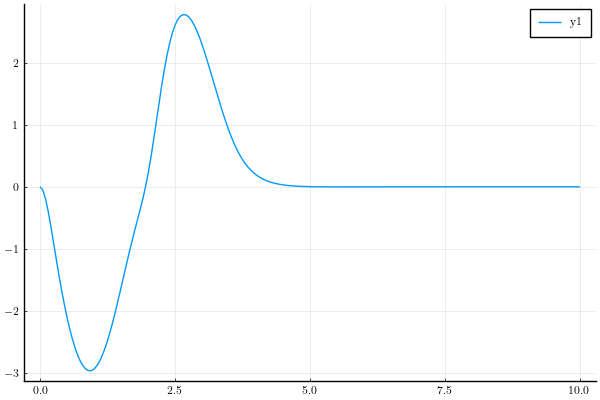

In [52]:
plot(thist, xtraj[1, :])
plot(thist, xtraj[2, :])

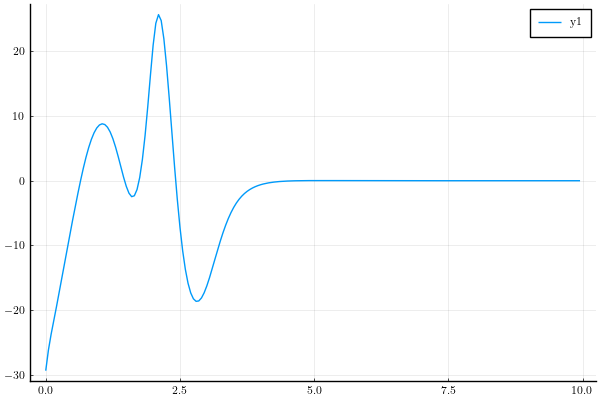

In [53]:
plot(thist[1:Nt-1], utraj)

In [58]:
Pkg.add("StaticArrays")

   Resolving package versions...
    Updating `~/Documents/optimal-control-notes-code/code/with-notes/introduction-to-nonlinear-trajectory-optimization/Project.toml`
  [90137ffa] + StaticArrays v1.6.2
  No Changes to `~/Documents/optimal-control-notes-code/code/with-notes/introduction-to-nonlinear-trajectory-optimization/Manifest.toml`


In [59]:
using TrajOptPlots
using MeshCat
using StaticArrays

vis = Visualizer()
render(vis)

┌ Info: MeshCat server started. You can open the visualizer by visiting the following URL in your browser:
└ http://127.0.0.1:8700


MeshCat.DisplayedVisualizer(MeshCat.CoreVisualizer(MeshCat.SceneTrees.SceneNode(nothing, nothing, Dict{String, Vector{UInt8}}(), nothing, Dict{String, MeshCat.SceneTrees.SceneNode}()), Set{Any}(), ip"127.0.0.1", 8700))

In [60]:
TrajOptPlots.set_mesh!(vis, a)

MeshCat Visualizer with path /meshcat/robot/link1/joint at http://127.0.0.1:8700

In [61]:
X1 = [SVector{4}(x) for x in eachcol(xtraj)];
visualize!(vis, a, thist[end], X1)